# Benchmark 6: RPC latency between Raft nodes
Round-trip time of the peer-to-peer AppendEntries RPC (`networking/rpc.c`), measured leader-side against its own clock - distinct from benchmarks 1/2/4/5, which all measure the client-facing HTTP API.

Each repeat runs two phases on the same cluster: `idle` (no client traffic, every AppendEntries is an empty heartbeat) and `writeLoad` (background clients hammering the leader with INSERTs, so AppendEntries mostly carry real entries - `numEntries` is logged per sample). The total round trip is also split into `queueUs` (network transit + follower-side processing + this leader's own per-peer job-queue wait) and `lockWaitUs` (time spent specifically waiting to acquire `raftNodeLock` once the response reaches the front of that queue) - see `raft/callbacks.c`'s `handleAppendEntriesResponse`. Run `bench/06-rpc-latency.sh` first.

In [1]:
import sys
sys.path.insert(0, ".")
import matplotlib.pyplot as plt
from plot_style import load, agg


In [2]:
df = load("rpc-latency.csv")
cluster_sizes = sorted(df["clusterSize"].unique())
print(f"{len(df)} individual RPC round trips captured across {df['run'].nunique()} runs per (clusterSize, scenario), "
      f"clusterSizes={cluster_sizes}")
df.head()


226600 individual RPC round trips captured across 5 runs per (clusterSize, scenario), clusterSizes=[np.int64(3), np.int64(5)]


,run,clusterSize,scenario,peer,numEntries,latencyUs,queueUs,lockWaitUs
0,1,3,idle,1,0,522.493,521.632,0.861
1,1,3,idle,2,0,572.279,541.510,30.769
2,1,3,idle,2,0,292.702,292.011,0.691
3,1,3,idle,1,0,350.614,349.922,0.692
4,1,3,idle,1,0,355.864,355.082,0.782


In [3]:
summary = df.groupby(["clusterSize", "scenario"]).agg(
    n=("latencyUs", "size"),
    meanUs=("latencyUs", "mean"),
    p50Us=("latencyUs", lambda s: s.quantile(0.5)),
    p90Us=("latencyUs", lambda s: s.quantile(0.9)),
    p99Us=("latencyUs", lambda s: s.quantile(0.99)),
    fracOver1ms=("latencyUs", lambda s: (s > 1000).mean()),
    meanNumEntries=("numEntries", "mean"),
)
summary


n       meanUs     p50Us      p90Us        p99Us  \
clusterSize scenario                                                           
3           idle         6586   505.164996   426.892   532.6690   1737.87245   
            writeLoad   72474  1916.044649  1307.956  4001.2315   6626.45137   
5           idle        13181  1686.051597   438.014   734.4840  15566.34360   
            writeLoad  134359  2033.412309  1452.043  4166.2790   7399.70292   

                       fracOver1ms  meanNumEntries  
clusterSize scenario                                
3           idle          0.011843        0.000000  
            writeLoad     0.619063        2.389340  
5           idle          0.090661        0.000000  
            writeLoad     0.711780        2.282929

## Idle vs write-load latency distribution, per cluster size
Idle heartbeat latency is bimodal: most RPCs are fast, but occasionally a run locks into a state where a large fraction pay close to one `raftMain` tick's worth of extra delay (see below for what's now known and not known about why). Write-load latency is unimodal and shifted right instead - dominated by real replication cost, not this lock effect.

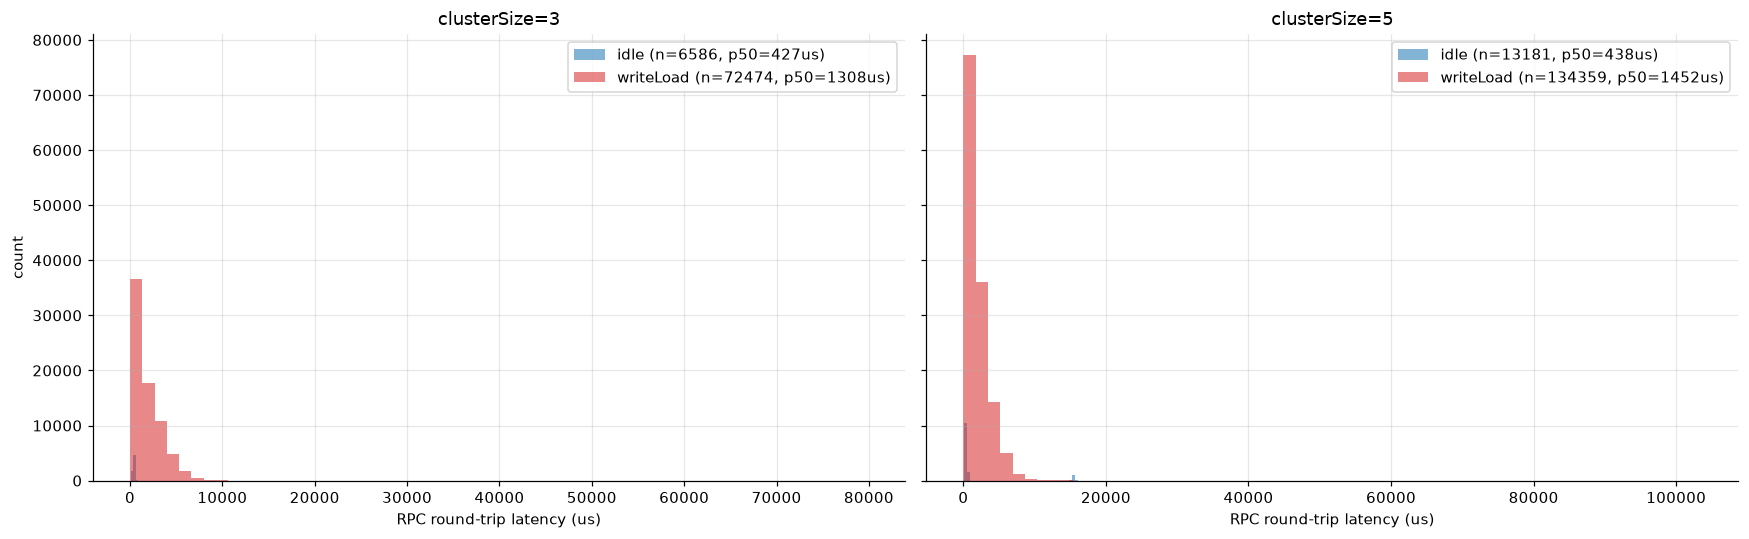

In [4]:
fig, axes = plt.subplots(1, len(cluster_sizes), figsize=(8 * len(cluster_sizes), 5), sharey=True)
if len(cluster_sizes) == 1:
    axes = [axes]

colors = {"idle": "tab:blue", "writeLoad": "tab:red"}
for ax, size in zip(axes, cluster_sizes):
    for scenario, color in colors.items():
        values = df.loc[(df["clusterSize"] == size) & (df["scenario"] == scenario), "latencyUs"]
        p50 = values.quantile(0.5)
        ax.hist(values, bins=60, alpha=0.55, color=color,
                label=f"{scenario} (n={len(values)}, p50={p50:.0f}us)")
    ax.set_xlabel("RPC round-trip latency (us)")
    ax.set_title(f"clusterSize={size}")
    ax.legend()
axes[0].set_ylabel("count")
plt.tight_layout()
plt.show()


### Why idle can look *worse* than writeLoad here

This is counterintuitive - the leader sends heartbeats every tick regardless of load, so `writeLoad` traffic is strictly heartbeats *plus* real entries, and should never be cheaper than `idle`. It isn't a benchmark artifact, and it isn't a simple "not settled yet" effect either. Looking at idle latency per repeat instead of pooled shows why: it's bistable. A given repeat either stays clean the whole time it runs, or at some point - not necessarily near the start - locks into a persistent degraded state that does not recover once entered. Write-triggered sends (irregular, on top of the regular tick) don't show this same bimodality.

**Update**: the original theory was that this came from each peer having one shared FIFO job queue/thread for both outbound sends and inbound response processing (`networking/worker.c`), so a heartbeat `SEND` job could sit in front of a response's `EXECUTE` job. That's since been split into independent `sendQueue`/`executeQueue` and worker threads per peer (see `rpc.h`/`worker.c`, and the "Core changes" section of the README) specifically to test the theory. **The split reduces but does not eliminate the lock.** Across a 10-repeat run after the split, 2/10 idle repeats still locked (both at N=5), versus 1-4/10 before - not a clear frequency win at this sample size - but the locked repeats were markedly less severe (14%/28% of samples over 1ms, vs a consistent ~49.5% pre-split). So the shared-queue design was a real contributor, but not the whole story; something else - most likely OS/TCP-level (no socket in this codebase sets `TCP_NODELAY`, so Nagle's algorithm is active, a classic source of periodic-traffic pathologies like this) - is still in play. Root-causing that further is out of scope here.

Because roughly half of even a locked repeat's samples are still fast, the per-sample **median** stays low regardless of lock state - it's specifically the slow portion that gets much slower. That's why the summary table above and the per-cluster-size comparison below lead with `p50Us` / median as the representative "typical" latency, and treat `meanUs` / `fracOver1ms` as tail-risk indicators rather than a stable per-configuration constant - with only `BENCH_REPEATS=5` samples per cell, whether the mean here reads high or low is dominated by how many repeats happened to lock in that particular run of the script.

In [5]:
idle = df[df["scenario"] == "idle"]
per_repeat = idle.groupby(["clusterSize", "run"])["latencyUs"].agg(
    meanUs="mean", medianUs="median", fracOver1ms=lambda s: (s > 1000).mean()
)
per_repeat["locked"] = per_repeat["meanUs"] > 2000
print(f"{per_repeat['locked'].sum()} / {len(per_repeat)} idle repeats locked into the degraded state")
per_repeat


2 / 10 idle repeats locked into the degraded state


meanUs  medianUs  fracOver1ms  locked
clusterSize run                                            
3           1     484.767646  422.1110     0.010638   False
            2     497.621411  429.2845     0.011398   False
            3     539.238542  461.2160     0.011416   False
            4     492.951957  418.6945     0.012121   False
            5     511.315634  395.8790     0.013636   False
5           1     539.931267  452.3005     0.011018   False
            2    2382.474059  410.3380     0.140371    True
            3     496.511570  444.5490     0.009513   False
            4     497.346224  419.4310     0.011742   False
            5    4506.460055  459.9685     0.280136    True

## Where the idle-scenario tail actually goes: queue/network time vs raft lock wait
Splitting the slow-mode samples (`latencyUs > 1ms`) into `queueUs` and `lockWaitUs` shows the delay is almost entirely `queueUs` - i.e. it happens before the response ever reaches `raftNodeLock`, not because the lock itself is contended. `raftNodeLock` contention was ruled out this way early on; see the section above for what was and wasn't later confirmed about the rest of the `queueUs` path.

In [6]:
slow_idle = df[(df["scenario"] == "idle") & (df["latencyUs"] > 1000)]
slow_idle.groupby("clusterSize")[["latencyUs", "queueUs", "lockWaitUs"]].median()


,latencyUs,queueUs,lockWaitUs
clusterSize,,,
3,6414.986,6379.628,0.9015
5,15346.198,15339.740,0.9420


## Mean latency vs cluster size, idle vs write-load
Mean +/- stddev per cluster size (computed per-run first so repeats stay independent samples, then averaged across runs). Cluster size matters a lot under idle heartbeat traffic (more peers -> more contention on the shared per-peer queue) but barely matters once the leader is write-loaded and latency is dominated by real replication cost instead.

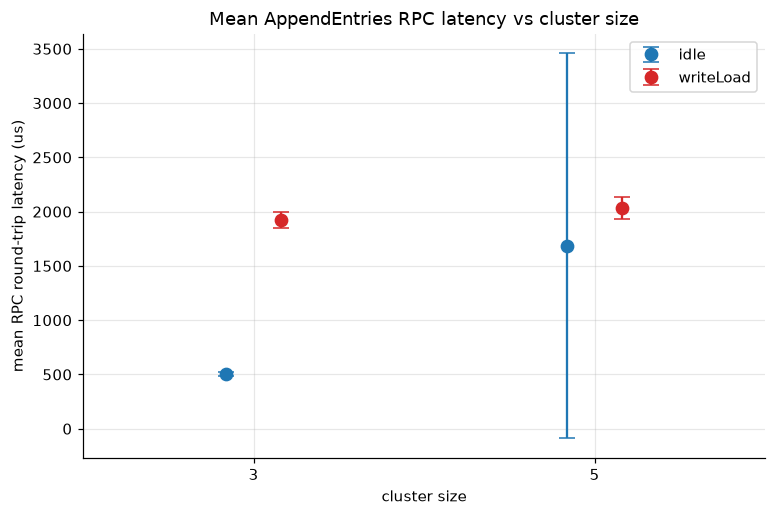

In [7]:
per_run_mean = df.groupby(["clusterSize", "scenario", "run"])["latencyUs"].mean().reset_index()

fig, ax = plt.subplots()
offsets = {"idle": -0.08, "writeLoad": 0.08}
for scenario, color in colors.items():
    grouped = agg(per_run_mean[per_run_mean["scenario"] == scenario], ["clusterSize"], "latencyUs")
    xs = [cluster_sizes.index(s) + offsets[scenario] for s in grouped["clusterSize"]]
    ax.errorbar(xs, grouped["mean"], yerr=grouped["std"], fmt="o", color=color,
                markersize=8, capsize=5, elinewidth=1.5, label=scenario)

ax.set_xticks(range(len(cluster_sizes)))
ax.set_xticklabels([str(s) for s in cluster_sizes])
ax.set_xlim(-0.5, len(cluster_sizes) - 0.5)
ax.set_xlabel("cluster size")
ax.set_ylabel("mean RPC round-trip latency (us)")
ax.set_title("Mean AppendEntries RPC latency vs cluster size")
ax.legend()
plt.show()
